<header>
   <p  style='font-size:36px;font-family:Arial; color:#F0F0F0; background-color: #00233c; padding-left: 20pt; padding-top: 20pt;padding-bottom: 10pt; padding-right: 20pt;'>
       Simplify Text Analytics with Teradata's Generative AI functions
  <br>
       <img id="teradata-logo" src="https://storage.googleapis.com/clearscape_analytics_demo_data/DEMO_Logo/teradata.svg" alt="Teradata" style="width: 125px; height: auto; margin-top: 20pt;">
    </p>
</header>

Modern data teams need AI capabilities where their data lives. Teradata's integration with AWS Bedrock enables end users, data engineers, and data scientists to apply large language models directly within their existing tools and pipelines, with enterprise security and governance built in.

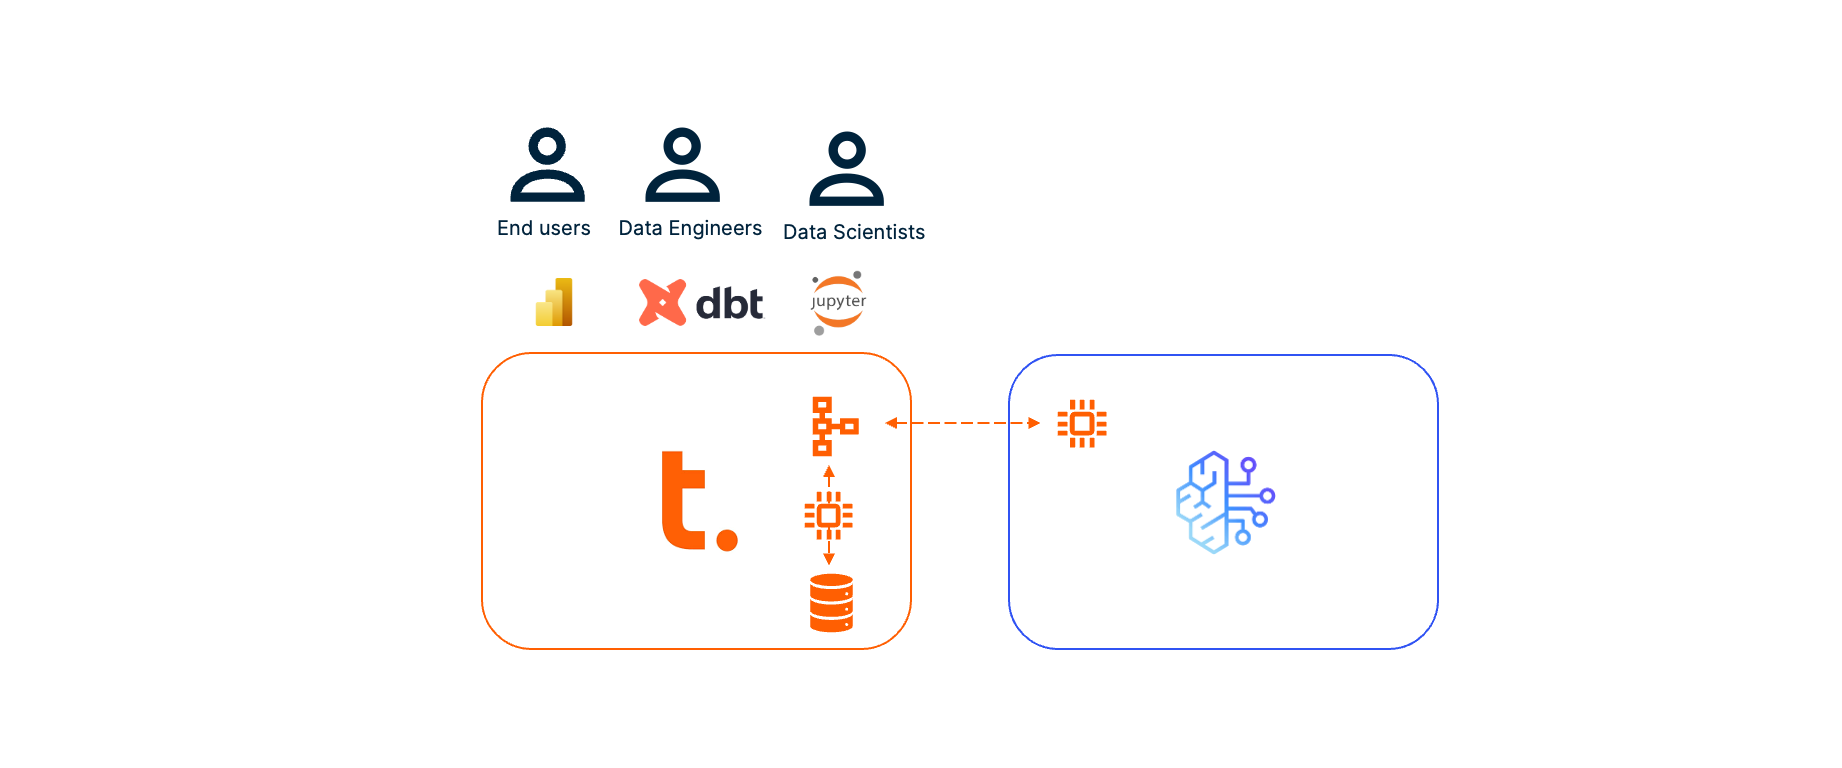


Teradata's in-database GenAI operators bring Bedrock's powerful language models directly into your data workflows. .
Teradata coordinates LLM processing and data operations within the database itself. Bedrock credentials are securely managed using classical RBAC policies, while GenAI operators seamlessly integrate into existing SQL queries and data pipelines.

## Analyzing Customer Complaints with GenAI

Traditionally, performing sentiment analysis, summarization, and translation on customer complaints means **extracting data, calling multiple external APIs, managing credentials, handling errors, and loading results back** — a complex pipeline with significant data movement and latency.

**With Teradata's GenAI operators, the entire workflow becomes a simple SQL query**. Sentiment, summarization, and translation happen in-database using AWS Bedrock models, eliminating data movement while maintaining enterprise security. Here's how it works.

In [ ]:
%lsconnect

In [5]:
%addconnect  name=VCL, user=<your db user name>, host=<you vantage system url>

Success: 'VCL' connection added

In [127]:
%connect VCL

Connected: 'VCL' connection activated for user 'data_engineer'


## CSP Credentials

Create an authorization object to store the user and secrets with access to the LLM service you want to use.
In this example, we will use AWS.

In [98]:
CREATE AUTHORIZATION td_aws_genai_auth
       user '...'
       password '...'

Success: 0 rows affected

We can use this along model invocation arguments to call a LLM on bedrock:

```
AWS_Bedrock_CSP_LLM_arguments
(
    ApiType('aws')
    [AUTHORIZATION([DatabaseName.]AuthorizationObjectName] 
    |{
    AcessKey('<aws access key>')
    SecretKey('<aws secret key>')|
    [SessionKey('<aws_session_key>')]
    }
    Region('<aws region>')
    ModelName('<bedrock-model-name>')
    [ModelArgs('{"Top_P":"top_p","Top_K":"top_k"}')]
)
```

## TextAnalyticsAI Functions

The Teradata AI Text analytics functions provides over 11 built-in generative AI functions for powerful in-database NLP capabilities leveraging external LLM prividers:

- **`AI_Classify()`** – Classify text into predefined categories
- **`AI_AnalyzeSentiment()`** – Perform sentiment analysis
- **`AI_DetectLanguage()`** – Detect the language of a text
- **`AI_Embeddings()`** – Generate embeddings for similarity search
- **`AI_RecognizeEntities()`** – Extract named entities
- **`AI_RecognizePiiEntities()`** – Detect and label PII entities
- **`AI_ExtractKeyPhrases()`** – Identify key phrases in text
- **`AI_MaskPii()`** – Mask personally identifiable information (PII)
- **`AI_SentenceSimilarity()`** – Measure semantic similarity between sentences
- **`AI_Summarize()`** – Generate summaries of longer documents
- **`AI_Translate()`** – Translate text between languages


## Data overview

In [126]:
sel top 10 * from "DEMO_ComplaintAnalysis"."Consumer_Complaints" 

,date_received,product,sub_product,issue,sub_issue,consumer_complaint_narrative,company_public_response,company,state,zip_code,tags,consumer_consent_provided,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,consumer_disputed,complaint_id
1,2022-08-25,"Money transfer, virtual currency, or money service",Domestic (US) money transfer,Fraud or scam,,"I have an discover high yield saving account and not been used recently. But XXXX, I saw there is one {$1800.00} transaction from my other account to this account which is for sure not done by me. After I login my discover account, I saw the money is been sent through XXXX to multiple unknow recipents. Those are for sure fraud, and I have no idea why discover bank could let that happen, which means the secruity of the bank is just bad. After I contact them, they insisted those are my liability and they refuse to investigate on the fraud and refund me money. They even froze/close my account to avoid me to login the account to grab detail information.",,DISCOVER BANK,CA,92620,,Consent provided,Web,2022-08-25,Closed with explanation,Yes,,5915083
2,2022-08-25,Debt collection,Credit card debt,Attempts to collect debt not owed,Debt is not yours,"DISCOVER FINANCIAL SERVICES claims that I owe them a debt yet they CAN NOT prove it, even though I have repeatedly given them chances to prove it by sending them letters with certified mail asking them to provide me with a VALIDATION OF DEBT as per federal law. I sent them a CONDITIONAL ACCEPTANCE in which they did not respond with their proof of claim or the required info, therefore binding them to my new TERMS AND CONDITIONS. I have attached all the letters I have sent proving that I have indeed exhausted all administrative remedies. I do NOT owe a debt and my ALL CAPITAL LETTERS name, aka my legal fiction XXXX, aka my XXXX XXXX XXXX XXXX, is where the credit came from via my SOCIAL SECURITY card, which is a TRUST account, making ME the ORIGINAL CREDITOR.",,DISCOVER BANK,FL,XXXXX,,Consent provided,Web,2022-08-25,Closed with explanation,Yes,,5918469
3,2022-08-25,Checking or savings account,Checking account,Managing an account,Deposits and withdrawals,"I recently opened a bank account with Discover. I received a check of {$1800.00} from XXXX after having a wreck. I used Discover mobile deposit to cash that check on XX/XX/XXXX2022. Yesterday on XX/XX/XXXX Discover emailed me stating they noticed suspicious activity on my account and to call them for more info. When I called I was told my account had been closed and they would be mailing my funds via a check. They also said that the check would not be sent until 60 days after the initial deposit. I asked to speak with a manager but the Discover agent refused. I asked to know why my account was closed and the Discover agent refused. I called XXXX to cancel the check but they let me know since the check is seen as cashed in their system, there is nothing they can do. Why didnt Discover call and verify the check with XXXX XXXX Why was the check cashed if it was suspicious? Discover has robbed me. I have been stolen from.",,DISCOVER BANK,TN,37066,,Consent provided,Web,2022-08-25,Closed with explanation,Yes,,5915075
4,2022-08-25,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Incorrect information on your report,Information belongs to someone else,I filed an FTC report and have a fraud alert on my account. I have mailed and called each major credit bureau and asked the fraudulent item to be removed to no avail. Mailed letters to all three on XX/XX/2022 XX/XX/2022 I have also disputed multiple times via their websites over the past year XXXX XXXX XXXX The account is with Discover Bank it has a balance of XXXX,,DISCOVER BANK,GA,30087,,Consent provided,Web,2022-08-25,Closed with explanation,Yes,,5917616
5,2022-08-26,Credit card or prepaid card,General-purpose credit card or charge card,"Other features, terms, or problems",Problem w

### Sentiment extraction

Generally, the sentiment expressed in complains is negative, let's check using the `AI_AnalyzeSentiment` function to be sure:

In [128]:
SELECT date_received, product, consumer_complaint_narrative, Sentiment
FROM AI_AnalyzeSentiment(
    ON (
        SELECT * FROM "DEMO_ComplaintAnalysis"."Consumer_Complaints" 
        QUALIFY ROW_NUMBER() OVER (ORDER BY "date_received")<11
    ) AS InputTable
    USING
        Authorization(td_aws_genai_auth)
        ModelName('us.amazon.nova-premier-v1:0')
        ApiType('aws')
        Region('us-east-1')
        TextColumn('consumer_complaint_narrative')
) AS sqlmr

,date_received,product,consumer_complaint_narrative,Sentiment
1,2015-03-20,Credit card,"I have been a Discover credit card holder since 2007. During my entire membership with Discover, I was never late with payments, and always stayed under my credit line, and never charged my credit card for any purposes other than making a legitimate purchase. About a month ago, without any notice in advance, Discover closed my account and thereby wiped out my existing cashback rewards of {$300.00}. I contacted the company and demanded for an explanation. However, the only reason I got is "" we are no longer able to meet your servicing needs '', and I was told the rewards will be mailed to me in a check. Now, after 6 weeks, I still have n't received any check from Discover regarding my rewards. I respectfully urge the CFPB to take this matter seriously and to look into this case. We consumers are powerless to protect ourselves from discriminatory actions like this.",negative
2,2015-03-21,Credit card,"XXXX offered a {$100.00} gift card when applying for aDiscoverXXXX Card. I clicked on the link, applied and compliedwith the requirements. The requirement was to make XXXXpurchase with the card within 3 months. It did not say thatthe purchase had to be with XXXX. After a few months, Icontacted the bank, and they said they knew nothing of theoffer. I contacted them again and the management saidI did not apply for the right card. XXXX denied anyknowledge of the offer, although it was on their website. I would not have applied for the card, but for the offer.",negative
3,2015-03-22,Credit card,"On XXXX XXXX and XXXX, 2015 ( as well several phone calls and chat sessions with Discover Card customer service ), I made inquiries to why a payment of {$61.00} that was posted to my Discover Card account on XXXX XXXX, 2015, did not have the funds withdrawn from my financial institution, XXXX XXXX XXXX XXXX XXXX in XXXX, NC, until XXXX XXXX, 2015. Nobody at either Discover Card or XXXX XXXX ' XXXX XXXX could give me a direct answer. Instead, I got the "" pass the buck '' routine. Neither financial institution should be allowed to treat customers this way. I have documentation available as proof of these events taking place.",negative
4,2015-03-22,Credit card,"In XXXX XXXX my checking acct was compromised that my credit card payment was auto-pay through. Since then I made monthly money order payments. My balance in XX/XX/XXXX was {$2000.00}. I sent 4 ) {$200.00} payments. I do NOT use the card for purchases & the interest is about {$3.00} a month. My balance is still {$1400.00}. I am clearly not credited for my XX/XX/XXXX payment. My bill went up that month instead of down. They insist that I was credited. There is some confusion because they repeatedly tried getting the payment through the bank, even though I told them not to. So they credited the bank payment then added it back on repeatedly. But it should n't take a genius to do the math. {$2000.00} minus {$800.00} is {$1200.00} not {$1400.00}. I called twice & wrote a letter & keep getting the same answer.",negative
5,2015-03-22,Debt collection,"I am being accused of having a Discover Card debt that I did n't pay off, so Discover has turned over the account to another company ; XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX to harass me. I knew nothing about this, I 've NEVER used a credit card, the name is not even my legal name, now a sheriff served my mom papers where this attorney office is threatening to seize my properties! This is so wrong to do to people! I 'VE NEVER OPENED A CREDIT CARD!!!!",negative
6,2015-03-23,Bank account or service,"A Discover Card rep told me he cancelled a payment pending for two days later, but it was not cancelled. It will cost me {$20.00} to stop payment or a {$35.00} insufficient funds charge.",negative
7,2015-03-23,Credit card,I attempted to apply for a Discover Card Online. The system did a hard credit pull and then disconnected me from the application process. I called in 

### Generating summary

We can use the LLM co-processor to summarize content using the `AI_TextSummarize` function:

In [101]:
drop table complaints_summary

Success: 17 rows affected

In [102]:
create table complaints_summary as
(
    
SELECT Complaint_id, "Summary" Summary_txt, consumer_complaint_narrative Original_txt
FROM AI_TextSummarize(
    ON (
        SELECT * FROM "DEMO_ComplaintAnalysis"."Consumer_Complaints" 
        QUALIFY ROW_NUMBER() OVER (ORDER BY "date_received")<11
    ) AS InputTable
    USING
        Authorization(td_aws_genai_auth)
        ModelName('us.amazon.nova-premier-v1:0')
        ApiType('aws')
        Region('us-east-1')
        TextColumn('consumer_complaint_narrative')
) AS sqlmr

) with data;

Success: 0 rows affected

In [103]:
sel * from complaints_summary;

,complaint_id,Summary_txt,Original_txt
1,1294631,"XXXX advertised a $100 gift card for applying for a Discover Card, but denied the offer existed after the applicant fulfilled the purchase requirement.","XXXX offered a {$100.00} gift card when applying for aDiscoverXXXX Card. I clicked on the link, applied and compliedwith the requirements. The requirement was to make XXXXpurchase with the card within 3 months. It did not say thatthe purchase had to be with XXXX. After a few months, Icontacted the bank, and they said they knew nothing of theoffer. I contacted them again and the management saidI did not apply for the right card. XXXX denied anyknowledge of the offer, although it was on their website. I would not have applied for the card, but for the offer."
2,1295531,"A Discover Card rep failed to cancel a pending payment, resulting in a {$20.00} stop fee or {$35.00} insufficient funds charge.","A Discover Card rep told me he cancelled a payment pending for two days later, but it was not cancelled. It will cost me {$20.00} to stop payment or a {$35.00} insufficient funds charge."
3,1307175,"After job losses, Discover enrolled us in payment assistance programs; despite timely payments, they now charge 24.99% interest and refuse to lower it for five years.","Because we had dual job losses a few years back, Discover placed us on a few programs to assist us with our payments. We made every payment owed. Our last statement showed that they are now charging us 24.99 % interest. Discover now says that our programs are over and thet we have to wait FIVE years before they will consider lowering the interest rate. It was never explained to us that they would charge such a high rate. We can not afford this. We can not make a dent in the principal because of the extremely high rate. We contacted Discover to ask for help, and were told "" too bad. '' I fail to understand why we are being punished when we complied with their programs, have faithfully made our payments to them, and are not behind at all."
4,1294888,"My credit card, compromised in XXXX XXXX, shows a {$1400.00} balance despite {$800.00} in payments, indicating an error as the company insists payments were credited.","In XXXX XXXX my checking acct was compromised that my credit card payment was auto-pay through. Since then I made monthly money order payments. My balance in XX/XX/XXXX was {$2000.00}. I sent 4 ) {$200.00} payments. I do NOT use the card for purchases & the interest is about {$3.00} a month. My balance is still {$1400.00}. I am clearly not credited for my XX/XX/XXXX payment. My bill went up that month instead of down. They insist that I was credited. There is some confusion because they repeatedly tried getting the payment through the bank, even though I told them not to. So they credited the bank payment then added it back on repeatedly. But it should n't take a genius to do the math. {$2000.00} minus {$800.00} is {$1200.00} not {$1400.00}. I called twice & wrote a letter & keep getting the same answer."
5,1294108,"Discover closed my account without notice, erasing $300 in cashback rewards, and hasn't sent a promised check despite weeks of waiting.","I have been a Discover credit card holder since 2007. During my entire membership with Discover, I was never late with payments, and always stayed under my credit line, and never charged my credit card for any purposes other than making a legitimate purchase. About a month ago, without any notice in advance, Discover closed my account and thereby wiped out my existing cashback rewards of {$300.00}. I contacted the company and demanded for an explanation. However, the only reason I got is "" we are no longer able to meet your servicing needs '', and I was told the rewards will be mailed to me in a check. Now, after 6 weeks, I still have n't received any check from Discover regarding my rewards. I respectfully urge the CFPB to take this matter seriously and to look into this case. We consumers are powerless to protect 

### Translating content

We can also translate content between languages using the `AI_TextTranslate` function:

In [119]:
SELECT *
FROM AI_TextTranslate(
    ON (
        SELECT * FROM complaints_summary
    ) AS InputTable
    USING
        Authorization(td_aws_genai_auth)
        ModelName('us.amazon.nova-premier-v1:0')
        ApiType('aws')
        Region('us-east-1')
        TextColumn('Summary_txt')
        TargetLang('portugese')
) AS sqlmr

,complaint_id,Summary_txt,Original_txt,Translation,Message
1,1294631,"XXXX advertised a $100 gift card for applying for a Discover Card, but denied the offer existed after the applicant fulfilled the purchase requirement.","XXXX offered a {$100.00} gift card when applying for aDiscoverXXXX Card. I clicked on the link, applied and compliedwith the requirements. The requirement was to make XXXXpurchase with the card within 3 months. It did not say thatthe purchase had to be with XXXX. After a few months, Icontacted the bank, and they said they knew nothing of theoffer. I contacted them again and the management saidI did not apply for the right card. XXXX denied anyknowledge of the offer, although it was on their website. I would not have applied for the card, but for the offer.","A XXXX anunciou um cartão-presente de $100 para quem solicitasse um Discover Card, mas negou que a oferta existisse depois que o candidato cumpriu o requisito de compra.",
2,1295531,"A Discover Card rep failed to cancel a pending payment, resulting in a {$20.00} stop fee or {$35.00} insufficient funds charge.","A Discover Card rep told me he cancelled a payment pending for two days later, but it was not cancelled. It will cost me {$20.00} to stop payment or a {$35.00} insufficient funds charge.","Um representante do Discover Card não conseguiu cancelar um pagamento pendente, resultando em uma taxa de suspensão de {$20,00} ou uma cobrança por fundos insuficientes de {$35,00}.",
3,1307175,"After job losses, Discover enrolled us in payment assistance programs; despite timely payments, they now charge 24.99% interest and refuse to lower it for five years.","Because we had dual job losses a few years back, Discover placed us on a few programs to assist us with our payments. We made every payment owed. Our last statement showed that they are now charging us 24.99 % interest. Discover now says that our programs are over and thet we have to wait FIVE years before they will consider lowering the interest rate. It was never explained to us that they would charge such a high rate. We can not afford this. We can not make a dent in the principal because of the extremely high rate. We contacted Discover to ask for help, and were told "" too bad. '' I fail to understand why we are being punished when we complied with their programs, have faithfully made our payments to them, and are not behind at all.","Após as perdas de emprego, a Discover nos inscreveu em programas de assistência ao pagamento; apesar dos pagamentos em dia, agora cobram 24,99% de juros e se recusam a baixá-los por cinco anos.",
4,1294888,"My credit card, compromised in XXXX XXXX, shows a {$1400.00} balance despite {$800.00} in payments, indicating an error as the company insists payments were credited.","In XXXX XXXX my checking acct was compromised that my credit card payment was auto-pay through. Since then I made monthly money order payments. My balance in XX/XX/XXXX was {$2000.00}. I sent 4 ) {$200.00} payments. I do NOT use the card for purchases & the interest is about {$3.00} a month. My balance is still {$1400.00}. I am clearly not credited for my XX/XX/XXXX payment. My bill went up that month instead of down. They insist that I was credited. There is some confusion because they repeatedly tried getting the payment through the bank, even though I told them not to. So they credited the bank payment then added it back on repeatedly. But it should n't take a genius to do the math. {$2000.00} minus {$800.00} is {$1200.00} not {$1400.00}. I called twice & wrote a letter & keep getting the same answer.","Meu cartão de crédito, comprometido em XXXX XXXX, mostra um saldo de {$1400,00} apesar de {$800,00} em pagamentos, indicando um erro já que a empresa insiste que os pagamentos foram creditados.",
5,1294108,"Discover closed my account without notice, erasing $300 in cashback rewards, and hasn't sent a promised check despite weeks of waiting.","I have been a Discover credit card holder since 2007. Du

## Ask LLM

The `AI_AskLLM` function is used to ask questions to the LLM based on the given context.

In this example, we wil pass two unrelated questions to our LLM with two contextual dataset and compute all the answers in batch.

In [8]:
CREATE MULTISET TABLE question (
    id int, 
    text_data varchar(500)
);

Success: 0 rows affected

In [9]:
CREATE MULTISET TABLE context_data (
    id int, 
    text_data varchar(500)
);

Success: 0 rows affected

In [120]:
del from context_data;
del from question;

--Questions
INSERT INTO question (1, 'What is this city name in discussion?');
INSERT INTO question (3, 'What individual has the highest net worth?');

--Context data
INSERT INTO context_data (1, 'The city of Islamabad is the capital of Pakistan and is known for its peaceful environment.');
INSERT INTO context_data (1, 'Islamabad is surrounded by the Margalla Hills and is famous for its modern infrastructure.');

INSERT INTO context_data (3, 'Musa has a net worth of $40,000, which includes his savings and assets.');
INSERT INTO context_data (3, 'Ali owns assets worth $20,000.');
INSERT INTO context_data (3, 'Sara has financial holdings valued at $20,000.');

Success: 17 rows affected

Success: 13 rows affected

Success: 1 rows affected

Success: 1 rows affected

Success: 1 rows affected

Success: 1 rows affected

Success: 1 rows affected

Success: 1 rows affected

Success: 1 rows affected

In [112]:
INSERT INTO context_data (2, 'Karachi, located on the southern coast of Pakistan, is a major economic hub.');
INSERT INTO context_data (2, 'The city is known for its beaches, ports, and diverse cultural heritage.');
INSERT INTO context_data (2, 'Karachi is part of the Sindh province and includes areas with desert landscapes.');

INSERT INTO context_data (4, 'Lahore, known as the cultural capital of Pakistan, is famous for its historical landmarks.');
INSERT INTO context_data (4, 'The city is home to the Lahore Fort and Badshahi Mosque, which are UNESCO World Heritage sites.');
INSERT INTO context_data (4, 'Lahore is also known for its vibrant food scene and colorful festivals.');

INSERT INTO context_data (5, 'Peshawar is a city in Khyber Pakhtunkhwa known for its rich history and ancient bazaars.');
INSERT INTO context_data (5, 'The city serves as a gateway to the historic Khyber Pass.');
INSERT INTO context_data (5, 'Peshawar is famous for its traditional cuisine and handcrafted goods.');

INSERT INTO context_data (6, 'The Great Wall of China is an ancient fortification built to protect against invasions.');
INSERT INTO context_data (6, 'The Wall stretches over 13,000 miles and is considered a marvel of engineering.');
INSERT INTO context_data (6, 'It is one of the most visited tourist attractions in the world, attracting millions of tourists every year.');

INSERT INTO question (2, 'What is in Karachi?');
INSERT INTO question (2, 'Does it have a desert?');

INSERT INTO question (4, 'Which city is known as the cultural capital of Pakistan?');
INSERT INTO question (4, 'What landmarks are UNESCO World Heritage sites in Lahore?');
INSERT INTO question (4, 'What is Lahore famous for besides its landmarks?');

INSERT INTO question (5, 'Which city serves as the gateway to the Khyber Pass?');
INSERT INTO question (5, 'What is Peshawar known for historically?');
INSERT INTO question (5, 'What type of goods is Peshawar famous for?');

INSERT INTO question (6, 'What is the purpose of the Great Wall of China?');
INSERT INTO question (6, 'How long is the Great Wall of China?');
INSERT INTO question (6, 'Why is the Great Wall of China considered a marvel?');



Success: 1 rows affected

Success: 1 rows affected

Success: 1 rows affected

Success: 1 rows affected

Success: 1 rows affected

...

Success: 1 rows affected

Success: 1 rows affected

Success: 1 rows affected

Success: 1 rows affected

Success: 1 rows affected

In [122]:
SELECT * FROM AI_AskLLM( 
      ON question AS InputTable partition by id
      ON context_data AS ContextTable partition by id
      USING   
      TextColumn('text_data')
      ApiType('aws')
      REGION('us-east-1')
      Authorization(td_aws_genai_auth)
      ModelName('us.amazon.nova-micro-v1:0')
      ContextColumn('text_data')
      Prompt('Provide clear and concise answer to this question:\n #QUESTION#\n\n Use this context data:\n #DATA#')
      DATAPOSITION('#DATA#')
      QUESTIONPOSITION('#QUESTION#')
      Accumulate('[0:]')
    ) as dt
    order by 1

,id,text_data,Response,Message
1,1,What is this city name in discussion?,The city in discussion is Islamabad.,
2,3,What individual has the highest net worth?,"Musa has the highest net worth, valued at $40,000.",


Compare the answer quality with different models:

In [123]:
SELECT * FROM AI_AskLLM( 
      ON question AS InputTable partition by id
      ON context_data AS ContextTable partition by id
      USING   
      TextColumn('text_data')
      ApiType('aws')
      REGION('us-east-1')
      Authorization(td_aws_genai_auth)
      ModelName('us.anthropic.claude-sonnet-4-5-20250929-v1:0')
      MODELOPERATION('converse')
      ContextColumn('text_data')
      Prompt('Provide clear and concise answer to this question:\n #QUESTION#\n\n Use this context data:\n #DATA#')
      DATAPOSITION('#DATA#')
      QUESTIONPOSITION('#QUESTION#')
      isDebug('true')
      Accumulate('[0:]')
    ) as dt
    order by 1

,id,text_data,Response,Message
1,1,What is this city name in discussion?,"Based on the context provided, the city name in discussion is **Islamabad**.",
2,3,What individual has the highest net worth?,"Based on the information provided:\n\n- Sara: $20,000\n- Ali: $20,000\n- Musa: $40,000\n\n**Musa has the highest net worth at $40,000.**",


<footer style="padding-bottom:35px; border-bottom:3px solid #91A0Ab">
    <div style="float:left;margin-top:14px">ClearScape Analytics™</div>
    <div style="float:right;">
        <div style="float:left; margin-top:14px">
            Copyright © Teradata Corporation - 2024, 2025, 2026. All Rights Reserved
        </div>
    </div>
</footer>